In [2]:
# ===== Rebuild plot_df if missing, then SAVE exactly-what-was-plotted (no ×Re) =====
import os, json, time, pathlib
import numpy as np
import pandas as pd

# -------------------- CONFIG (defaults if not already defined) --------------------
if "CSV_PATH" not in globals():
    CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"

if "Y_COLUMN" not in globals():
    Y_COLUMN = "Ratio_signed"
if "Y_LABEL" not in globals():
    Y_LABEL = r"$\langle -\tau:S\rangle / \langle 2\nu S:S\rangle$"

# family lengthscales / Ubar (only set if not already defined upstream)
if "LENGTHSCALES" not in globals():
    LENGTHSCALES = {
        "FILCOH":     2*np.pi/25.0,
        "MATURE":     2*np.pi/10.0,
        "CONDENSATE": 2*np.pi/3.0,
    }
if "UBAR" not in globals():
    UBAR = {
        "FILCOH":     0.39749,
        "MATURE":     0.31764,
        "CONDENSATE": 4.1913,
    }

if "CUT_MAX_XBASE" not in globals(): CUT_MAX_XBASE = {"FILCOH": None, "MATURE": None, "CONDENSATE": None}
if "CUT_MIN_XBASE" not in globals(): CUT_MIN_XBASE = {"FILCOH": None, "MATURE": None, "CONDENSATE": None}

# -------------------- Build plot_df if absent --------------------
def _normalize_family(x):
    s = str(x).strip().upper()
    if s.startswith("FILCOH"):  return "FILCOH"
    if s.startswith("MATURE"):  return "MATURE"
    if s.startswith("CONDENSATE"): return "CONDENSATE"
    return s

if "plot_df" not in globals():
    # Load base CSV
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]

    # Required cols check (graceful)
    required = {"family","dataset","nu","Delta",Y_COLUMN}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in CSV: {missing}")

    # sanitize families and numeric coercion
    df["family"] = df["family"].map(_normalize_family)

    def _to_num(s):
        s = s.astype(str).str.strip().str.replace(",", "", regex=False)
        s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
        return pd.to_numeric(s, errors="coerce")

    for c in ["nu","Delta",Y_COLUMN]:
        df[c] = _to_num(df[c])

    # attach L and Ubar
    df["L_family"]    = df["family"].map(lambda f: float(LENGTHSCALES.get(f, np.nan)))
    df["Ubar_family"] = df["family"].map(lambda f: float(UBAR.get(f, np.nan)))
    df = df[np.isfinite(df["L_family"]) & np.isfinite(df["Ubar_family"])]

    # Re and x/y
    df["Re_float"] = (df["Ubar_family"] * df["L_family"]) / df["nu"]
    df["x_base"]   = df["Delta"] / df["L_family"]
    df["y_val"]    = df[Y_COLUMN]

    # apply per-family Δ/L cuts on x_base
    mask = np.isfinite(df["x_base"]) & np.isfinite(df["y_val"]) & (df["x_base"] > 0)
    for fam in df["family"].dropna().unique():
        fam_mask = (df["family"] == fam)
        xmin = CUT_MIN_XBASE.get(fam)
        xmax = CUT_MAX_XBASE.get(fam)
        if xmin is not None: mask &= (~fam_mask) | (df["x_base"] >= float(xmin))
        if xmax is not None: mask &= (~fam_mask) | (df["x_base"] <= float(xmax))

    plot_df = df[mask].copy()

    # choose scales (for metadata only)
    pos_mask = (plot_df["y_val"] > 0)
    xscale = "log"
    yscale = "log" if pos_mask.any() else "symlog"

# -------------------- Save exactly what is (or would be) plotted --------------------
SAVE_DIR = pathlib.Path("out_ratios_enstrophy") / "plotted_export_noRe"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Build export with x = Delta/L_family (no ×Re), y = Ratio_signed, plus extras.
cols_base = [
    "family", "dataset",
    "nu", "Delta",
    "L_family", "Ubar_family", "Re_float",
    "x_base", "y_val",
]
have = [c for c in cols_base if c in plot_df.columns]
export_df = plot_df.loc[:, have].copy()

export_df = export_df.rename(columns={"x_base": "x_Delta_over_L", "y_val": "y_ratio_signed"})
export_df["N_exact"] = (2.0*np.pi / export_df["Delta"].to_numpy())
export_df["N_int"]   = np.rint(export_df["N_exact"]).astype(int)

export_df = export_df.sort_values(["family","Re_float","dataset","x_Delta_over_L"], kind="mergesort")

master_csv = SAVE_DIR / "plotted_points_noRe.csv"
export_df.to_csv(master_csv, index=False)

def _safe(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "._-+=" else "_" for ch in str(s))

for fam, fam_grp in export_df.groupby("family"):
    for re_val, re_grp in fam_grp.groupby("Re_float"):
        ds = str(re_grp["dataset"].iloc[0]) if "dataset" in re_grp.columns else "NA"
        re_str = f"{re_val:.2e}" if np.isfinite(re_val) else "NA"
        fname = SAVE_DIR / f"curve__{_safe(fam)}__Re_{_safe(re_str)}__{_safe(ds)}.csv"
        re_grp.to_csv(fname, index=False)

meta = {
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "source_csv_path": CSV_PATH,
    "exports": {
        "x_column": "x_Delta_over_L",
        "y_column": "y_ratio_signed",
        "extra_columns": [
            "family","dataset","nu","Delta","L_family","Ubar_family","Re_float","N_exact","N_int"
        ],
        "note": "x = Delta / L_family (no ×Re); y = Ratio_signed."
    },
    "plotting_view": {
        "xscale": locals().get("xscale", "log"),
        "yscale": locals().get("yscale", "log"),
        "multiply_x_by_Re": False
    },
    "cuts": {
        "CUT_MIN_XBASE": {k: (None if v is None else float(v)) for k, v in CUT_MIN_XBASE.items()},
        "CUT_MAX_XBASE": {k: (None if v is None else float(v)) for k, v in CUT_MAX_XBASE.items()},
    },
    "lengthscales": {k: float(v) for k, v in LENGTHSCALES.items()},
    "ubar":          {k: float(v) for k, v in UBAR.items()},
    "n_points_plotted": int(len(export_df)),
}
with open(SAVE_DIR / "plotted_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"[SAVE] Wrote {len(export_df)} plotted points to: {master_csv}")
print(f"[SAVE] Per-curve CSVs + metadata saved under: {SAVE_DIR}")


/tmp/ipykernel_1033075/760842598.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


[SAVE] Wrote 1800 plotted points to: out_ratios_enstrophy/plotted_export_noRe/plotted_points_noRe.csv
[SAVE] Per-curve CSVs + metadata saved under: out_ratios_enstrophy/plotted_export_noRe


[INFO] curves:        family          dataset      Re_float  #pts
0  CONDENSATE  condensate_1e-4  8.778238e+04   200
1  CONDENSATE  condensate_1e-5  8.778238e+05   200
2  CONDENSATE  condensate_1e-6  8.778238e+06   200
3      FILCOH      filcoh_1e-4  9.990013e+02   200
4      FILCOH      filcoh_1e-5  9.990013e+03   200
5      FILCOH      filcoh_1e-6  9.990013e+04   200
6      MATURE    maturevm_1e-4  1.995791e+03   200
7      MATURE    maturevm_1e-5  1.995791e+04   200
8      MATURE    maturevm_1e-6  1.995791e+05   200


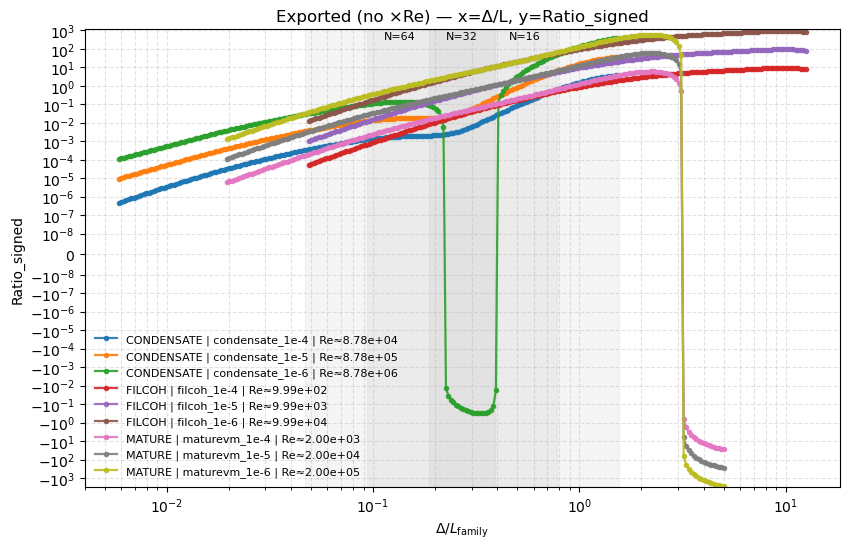

In [3]:
# ===== Load & Plot exported "exactly-what-was-plotted" points (no ×Re) =====
import os, glob, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_DIR = pathlib.Path("out_ratios_enstrophy") / "plotted_export_noRe"
MASTER   = SAVE_DIR / "plotted_points_noRe.csv"

if not MASTER.exists():
    raise FileNotFoundError(f"Master CSV not found: {MASTER}\nRun the export cell first.")

# -------- load master --------
df = pd.read_csv(MASTER)

# Sanity + sorting
need = {"family","dataset","Re_float","x_Delta_over_L","y_ratio_signed","N_exact","N_int",
        "nu","Delta","L_family","Ubar_family"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in master CSV: {missing}")

df = df.sort_values(["family","Re_float","dataset","x_Delta_over_L"], kind="mergesort")

# -------- quick summary --------
print("[INFO] curves:", df.groupby(["family","dataset","Re_float"]).size().reset_index(name="#pts"))

# ===== Plot helpers =====
def plot_all_curves(data: pd.DataFrame,
                    families=None,
                    re_min=None, re_max=None,
                    xlog=True, ylog=True,
                    title="Exported (no ×Re) — x=Δ/L, y=Ratio_signed",
                    mark_N=None):
    """
    families: list like ['FILCOH','MATURE'] or None for all
    re_min/re_max: numeric filters on Re_float (inclusive) or None
    mark_N: list of N to mark as vertical lines via their typical Δ/L ~ Δ/L_family
    """
    d = data.copy()
    if families is not None:
        famset = {f.upper() for f in families}
        d = d[d["family"].str.upper().isin(famset)]
    if re_min is not None:
        d = d[d["Re_float"] >= re_min]
    if re_max is not None:
        d = d[d["Re_float"] <= re_max]

    if d.empty:
        print("[WARN] No data after filters.")
        return

    plt.figure(figsize=(8.6, 5.6))
    # Unique styling per (family, dataset) to keep legend tidy; Re shown in label
    # (You can change this grouping if you prefer)
    for (fam, ds, Re), grp in d.groupby(["family","dataset","Re_float"], sort=False):
        grp = grp.sort_values("x_Delta_over_L")
        label = f"{fam} | {ds} | Re≈{Re:.2e}"
        plt.plot(grp["x_Delta_over_L"], grp["y_ratio_signed"], lw=1.6, marker="o", ms=3.0, alpha=0.9, label=label)

    if xlog: plt.xscale("log")
    if ylog:
        # If signed data present, fall back gracefully to symlog
        if (d["y_ratio_signed"] <= 0).any():
            plt.yscale("symlog", linthresh=1e-8)
        else:
            plt.yscale("log")

    plt.xlabel(r"$\Delta / L_{\rm family}$")
    plt.ylabel("Ratio_signed")
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.35)
    plt.legend(fontsize=8, ncol=1, frameon=False)
    plt.tight_layout()

    # Optional N markers (use median L per family for a rough guide)
    if mark_N:
        famL = d.groupby("family")["L_family"].median()
        # Draw a vertical line for each N using the median L across families (or per family if you prefer)
        for N in mark_N:
            Delta = 2.0*np.pi / float(N)
            # If multiple families, draw a faint band for the range of Δ/L across families
            x_vals = Delta / famL.values
            x_min, x_max = float(np.min(x_vals)), float(np.max(x_vals))
            if x_min == x_max:
                plt.axvline(x_min, ls=":", lw=1.2, color="gray")
            else:
                plt.axvspan(x_min, x_max, color="gray", alpha=0.08)
            plt.text(np.sqrt(x_min*x_max), plt.gca().get_ylim()[1]*0.8, f"N={N}",
                     ha="center", va="top", fontsize=8)

    plt.show()

# ===== Example usages =====
# 1) Plot everything
plot_all_curves(df, mark_N=[16,32,64])

# 2) Plot just MATURE curves
# plot_all_curves(df, families=["MATURE"], mark_N=[16,32,64])

# 3) Restrict to moderate Re range
# plot_all_curves(df, re_min=1e3, re_max=1e6, mark_N=[16,32,64])
